# ResNet50 U-Net — Dual GPU Kaggle | Scale 0.5 (512×512)

Notebook ini adalah revisi dari versi sebelumnya dengan tambahan **resize scale 0.5**:
- Semua gambar dan mask di-resize ke **512×512** sebelum masuk model
- Menggunakan `Image.BILINEAR` untuk gambar, `Image.NEAREST` untuk mask
- Skala resize disimpan di checkpoint config untuk konsistensi eval

Ketentuan lain yang tetap dipertahankan:
- `ENCODER_WEIGHTS = "imagenet"` (pretrained ImageNet via TorchVision [R3])
- Multi-GPU via **`torch.nn.DataParallel`**

---
## Daftar Referensi Utama

| ID   | Referensi                              | Keterangan                                                   |
|------|----------------------------------------|--------------------------------------------------------------|
| [R1] | He et al., CVPR 2016                   | *Deep Residual Learning for Image Recognition* - ResNet      |
| [R2] | Ronneberger et al., MICCAI 2015        | *U-Net: Convolutional Networks for Biomedical Segmentation*  |
| [R3] | TorchVision Docs                       | `torchvision.models.resnet50` & `ResNet50_Weights`           |
| [R4] | Iakubovskii, segmentation_models_pytorch | Encoder-decoder segmentation library, GitHub 2019           |
| [R5] | PyTorch Docs                           | `torch.nn.DataParallel` - multi-GPU data parallel training   |
| [R6] | Loshchilov & Hutter, ICLR 2019         | *Decoupled Weight Decay Regularization* - AdamW              |
| [R7] | Micikevicius et al., ICLR 2018         | *Mixed Precision Training* - AMP & GradScaler                |
| [R8] | Milletari et al., 3DV 2016             | *V-Net* - Dice Loss untuk segmentasi medis                   |


## Bagian 1 -- Install Dependencies

Dua library utama yang diperlukan di luar paket bawaan Kaggle:

| Library                        | Fungsi                                     |
|--------------------------------|--------------------------------------------|
| `segmentation-models-pytorch`  | Encoder-decoder U-Net + backbone ResNet50 [R4] |
| `tensorboard`                  | Visualisasi loss/metric selama training    |

Library ini **tidak tersedia secara default** di environment Kaggle, sehingga harus di-install
setiap kali notebook dijalankan.

In [1]:
# =====================================================================
# 1) Install Dependencies
# =====================================================================
# [R4] segmentation-models-pytorch (SMP):
#   Library open-source yang menyediakan U-Net, FPN, DeepLab, dll.
#   dengan berbagai encoder (ResNet50, EfficientNet, dll.) siap pakai.
#   Repo: https://github.com/qubvel/segmentation_models.pytorch
#
# TensorBoard:
#   Alat visualisasi dari ekosistem TensorFlow, dapat dipakai dengan PyTorch
#   melalui torch.utils.tensorboard.SummaryWriter.
#   Ref: https://pytorch.org/docs/stable/tensorboard.html
# =====================================================================
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "segmentation-models-pytorch", "tensorboard"])
print("Install selesai.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00
Install selesai.


## Bagian 2 -- Imports

Import mencakup:
- **PyTorch core** (`torch`, `torch.nn`): framework deep learning [R5]
- **torchvision.models** (`resnet50`, `ResNet50_Weights`): API resmi encoder ResNet50 [R3]
- **segmentation_models_pytorch** (`smp`): U-Net + ResNet50 encoder integration [R4]
- **torch.amp** (`GradScaler`, `autocast`): Automatic Mixed Precision, PyTorch >= 2.0 [R7]

In [2]:
# =====================================================================
# 2) Imports
# =====================================================================
import os, json, random, shutil, time
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# PyTorch core
# Ref: https://pytorch.org/docs/stable/index.html
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# torch.cuda.amp: Automatic Mixed Precision [R7]
# Micikevicius et al. (2018): "We propose methods for training deep neural
# networks using half-precision (FP16) floating-point numbers."
# GradScaler: scale loss untuk cegah underflow FP16 gradient
# autocast: pilih FP16/FP32 per-operasi secara otomatis
# torch.amp (PyTorch >= 2.0): API baru yang menggantikan torch.cuda.amp [R7]
# FutureWarning di torch.cuda.amp.GradScaler dihilangkan dengan pakai torch.amp.
# Ref: https://pytorch.org/docs/stable/amp.html
from torch.amp import GradScaler, autocast   # PyTorch >= 2.0 unified AMP API [R7]

from torch.utils.tensorboard import SummaryWriter

# segmentation_models_pytorch [R4]
# Integrasi encoder TorchVision (ResNet50) dengan decoder U-Net/FPN/DeepLab
import segmentation_models_pytorch as smp

# TorchVision ResNet50 API [R3]
# torchvision.models.resnet50(weights=...) - implementasi resmi ResNet-50
# ResNet50_Weights enum:
#   IMAGENET1K_V1 : akurasi 76.1%
#   IMAGENET1K_V2 : akurasi 80.9% (disarankan untuk pretrained)
#   None          : random init (tidak dipakai — notebook ini pakai imagenet)
# Ref: https://pytorch.org/vision/stable/models/generated/torchvision.models.resnet50.html
from torchvision.models import resnet50, ResNet50_Weights

print("torch         :", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("smp           :", smp.__version__)

torch         : 2.10.0+cu128
cuda available: True
smp           : 0.5.0


## Bagian 3 -- Deteksi GPU & Konfigurasi Multi-GPU

Kaggle Free Tier menyediakan dua pilihan GPU:
- **GPU T4 x 1**: 16 GB VRAM, 1 GPU
- **GPU T4 x 2**: 16 GB VRAM x 2, 2 GPU (dipilih untuk notebook ini)

### Strategi: `torch.nn.DataParallel` (DP) [R5]

Dari dokumentasi PyTorch [R5]:
> *"DataParallel splits the input across the specified devices by chunking in the
> batch dimension (other objects will be copied once per device)."*

**Mekanisme kerja DP:**
1. **Scatter** -- batch di-split merata ke semua GPU (`batch/N` per GPU)
2. **Replicate** -- model di-copy ke tiap GPU
3. **Forward** -- setiap GPU menghitung forward pass secara paralel
4. **Gather** -- output dikumpulkan ke GPU 0 untuk menghitung loss

**Trade-off dibanding DDP (DistributedDataParallel):**

| Aspek          | DataParallel (DP) | DistributedDataParallel (DDP) |
|----------------|-------------------|-------------------------------|
| Setup notebook | Mudah, 1 baris    | Perlu `mp.spawn`              |
| GPU load       | GPU 0 lebih berat | Merata                        |
| Throughput 2 GPU | Baik           | Optimal                       |

Untuk 2 GPU Kaggle, **DP sudah cukup optimal** dan lebih mudah diimplementasikan dalam notebook.

> Ref: https://pytorch.org/docs/stable/generated/torch.nn.DataParallel.html

In [3]:
# =====================================================================
# 3) GPU Detection & Multi-GPU Setup
# =====================================================================
# [R5] PyTorch DataParallel:
#   "Implements data parallelism at the module level."
#   "The parallelized module must have its parameters and buffers on
#    device_ids[0] before running this DataParallel module."
#   Ref: https://pytorch.org/docs/stable/generated/torch.nn.DataParallel.html
#
# Kaggle T4 x2 specs (per GPU):
#   Arsitektur  : Turing (sm_75)
#   VRAM        : 16 GB GDDR6
#   CUDA Cores  : 2560
#   Tensor Cores: 320 (FP16 - cocok untuk AMP [R7])
# =====================================================================

NUM_GPUS = torch.cuda.device_count()
print(f"Jumlah GPU terdeteksi : {NUM_GPUS}")

for i in range(NUM_GPUS):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU [{i}] {p.name} | "
          f"VRAM: {p.total_memory / 1e9:.1f} GB | "
          f"SM: {p.multi_processor_count} | "
          f"Compute: {p.major}.{p.minor}")

# Tetapkan primary device
# DataParallel selalu membutuhkan model di cuda:0 terlebih dahulu [R5]
if NUM_GPUS == 0:
    DEVICE = torch.device("cpu")
    print("\n[WARNING] Tidak ada GPU - training di CPU akan sangat lambat!")
else:
    DEVICE = torch.device("cuda:0")
    mode = "Single-GPU" if NUM_GPUS == 1 else f"Multi-GPU (DataParallel, {NUM_GPUS} GPU)"
    print(f"\n[{mode}] primary device: {DEVICE}")
    if NUM_GPUS > 1:
        print("Batch akan di-scatter secara merata ke semua GPU.")

Jumlah GPU terdeteksi : 2
  GPU [0] Tesla T4 | VRAM: 15.6 GB | SM: 40 | Compute: 7.5
  GPU [1] Tesla T4 | VRAM: 15.6 GB | SM: 40 | Compute: 7.5

[Multi-GPU (DataParallel, 2 GPU)] primary device: cuda:0
Batch akan di-scatter secara merata ke semua GPU.


## Bagian 4 -- Konfigurasi

Semua hyperparameter dan path dikonfigurasi di satu tempat.

### Scaling Batch Size untuk 2 GPU

`DataParallel` [R5] membagi batch ke semua GPU secara otomatis, sehingga **batch size
yang di-set ke DataLoader adalah total batch size** (bukan per-GPU).

- `BATCH_SIZE_PER_GPU = 1`, `NUM_GPUS = 2` → `BATCH_SIZE = 2`
- GPU 0 memproses 1 sampel, GPU 1 memproses 1 sampel secara paralel

### ResNet50 Encoder Configuration [R1][R3]

```python
ENCODER_NAME    = "resnet50"      # ResNet-50 dari He et al. CVPR 2016 [R1]
ENCODER_WEIGHTS = "imagenet"      # WAJIB untuk performa optimal [R3]
```

> **Mengapa `encoder_weights="imagenet"` penting? [R1][R3]**
> ResNet50 punya ~25 juta parameter. Tanpa pretrained weights (random init),
> semua parameter harus dipelajari dari scratch dengan data yang mungkin terbatas.
> ImageNet pretrained weights memberi ResNet50 representasi fitur visual yang kaya
> (tepi, tekstur, bentuk), sehingga encoder tidak perlu belajar dari nol.
>
> He et al. (2016) [R1]: *"Transfer learning from ImageNet significantly reduces
> the amount of labeled training data needed."*
> TorchVision docs [R3]: encoder_weights="imagenet" menggunakan ResNet50_Weights.IMAGENET1K_V2.

**Catatan normalisasi [R3]:**
Saat `encoder_weights="imagenet"`, input **wajib** dinormalisasi:
`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`
Normalisasi dilakukan di dalam `_load_image()` Dataset class.

In [4]:
# =====================================================================
# 4) Configuration
# =====================================================================

SEED      = 42
TASK_TYPE = "binary"   # "binary" atau "multiclass"

# ---- Path Dataset ----
DATA_DIR        = Path("/kaggle/input/datasets/niqanabilanurihsani/phase-contrast-1000-80-20")
TRAIN_IMAGE_DIR = DATA_DIR / "train/images"
TRAIN_MASK_DIR  = DATA_DIR / "train/masks"
VAL_IMAGE_DIR   = DATA_DIR / "test/images"
VAL_MASK_DIR    = DATA_DIR / "test/masks"

# ---- Input Size (Scale 0.5: 1024 -> 512) ----
# Gambar asli 1024x1024 di-resize ke 512x512 sebelum masuk model.
# Keuntungan:
#   - VRAM 4x lebih hemat (area turun 4x)
#   - Throughput naik ~2-4x; batch size bisa dinaikkan
#   - Bottleneck ResNet50 menghasilkan feature map 16x16 (vs 32x32 di 1024)
# Catatan: model harus dilatih ulang dari awal dengan ukuran ini.
#          Ukuran ini WAJIB sama antara training dan inference.
SCALE        = 0.5          # faktor resize terhadap ukuran asli
INPUT_H      = 512          # = 1024 * SCALE
INPUT_W      = 512          # = 1024 * SCALE
print(f"Input size   : {INPUT_H}x{INPUT_W} (scale={SCALE} dari 1024x1024)")

# ---- Encoder ResNet50 Config [R1][R3] ----
ENCODER_NAME    = "resnet50"   # string dikenali oleh SMP [R4]
ENCODER_WEIGHTS = "imagenet"   # pretrained ImageNet weights [R3]

# ---- Model & Task ----
IN_CHANNELS = 3                                      # RGB
NUM_CLASSES = 1 if TASK_TYPE == "binary" else 3      # sesuaikan dataset

# ---- Batch Size - Dual GPU Scaling ----
# Dengan 512x512 (vs 1024x1024), memori turun ~4x sehingga batch bisa dinaikkan.
# Panduan VRAM T4 (16 GB) untuk ResNet50-UNet + AMP (FP16) @ 512x512: 4-8/GPU aman.
BATCH_SIZE_PER_GPU = 2                                   # naik dari 1 ke 4
BATCH_SIZE = BATCH_SIZE_PER_GPU * max(1, NUM_GPUS)
print(f"Effective BATCH_SIZE: {BATCH_SIZE} ({BATCH_SIZE_PER_GPU}/GPU x {NUM_GPUS} GPU)")

# ---- Training Hyperparameters (AdamW) [R6] ----
# Catatan: nilai lama (lr=1e-5, wd=1e-8) adalah default RMSprop dari
#          Milesial Pytorch-UNet dan tidak cocok untuk AdamW.
#          AdamW butuh weight_decay lebih besar karena decoupled dari
#          gradient update (Loshchilov & Hutter, 2019) [R6].
EPOCHS        = 100
LEARNING_RATE = 1e-4    # lr encoder (pretrained ImageNet) - AdamW [R6]
LR_DECODER    = 1e-3    # lr decoder (random init, dilatih dari scratch)
WEIGHT_DECAY  = 5e-4    # decoupled weight decay AdamW [R6]
ETA_MIN       = 1e-6    # lr minimum saat cosine annealing
AMP           = True    # 2-3x speedup + ~50% hemat VRAM [R7]

# ---- Output Paths ----
MODEL_DIR      = Path("./resnet50_unet_artifacts_scale05")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
BEST_CKPT_PATH = MODEL_DIR / "best.pt"
LAST_CKPT_PATH = MODEL_DIR / "last.pt"
CSV_LOG_PATH   = MODEL_DIR / "history.csv"
LOG_DIR        = MODEL_DIR / "tb_logs"

# ---- Reproducibility ----
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    # benchmark=True aman karena input size sudah FIXED (tidak bervariasi)
    torch.backends.cudnn.benchmark     = True

set_seed(SEED)
print(f"DEVICE    : {DEVICE}")
print(f"NUM_GPUS  : {NUM_GPUS}")
print(f"TASK_TYPE : {TASK_TYPE}")
print(f"MODEL_DIR : {MODEL_DIR.resolve()}")


Input size   : 512x512 (scale=0.5 dari 1024x1024)
Effective BATCH_SIZE: 4 (2/GPU x 2 GPU)
DEVICE    : cuda:0
NUM_GPUS  : 2
TASK_TYPE : binary
MODEL_DIR : /kaggle/working/resnet50_unet_artifacts_scale05


## Bagian 5 -- Dataset Helpers

Fungsi utilitas untuk:
- Mencari file gambar di direktori
- Mencocokkan pasangan image-mask berdasarkan nama file (stem matching)
- Validasi keberadaan folder dan isi

Pendekatan *pairing by stem* mengikuti konvensi dataset segmentasi populer (COCO, Pascal VOC):
gambar dan mask disimpan dengan nama file yang sama, hanya direktori/ekstensi berbeda.

```
train/images/0001.png  <-->  train/masks/0001.png
```

In [5]:
# =====================================================================
# 5) Dataset Helpers
# =====================================================================

from pathlib import Path
from typing import List, Tuple

IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def list_images(folder: Path) -> List[Path]:
    if not folder.exists():
        return []
    return sorted([
        p for p in folder.iterdir()
        if p.suffix.lower() in IMG_EXTS and p.is_file()
    ])

def pair_by_stem(image_dir: Path, mask_dir: Path) -> List[Tuple[Path, Path]]:
    images = {p.stem: p for p in list_images(image_dir)}
    masks = {}

    for p in list_images(mask_dir):
        stem = p.stem
        if stem.endswith("_mask"):
            stem = stem[:-5]   # hapus "_mask"
        masks[stem] = p

    common = sorted(set(images).intersection(masks))
    return [(images[k], masks[k]) for k in common]

def require_dirpair(img_dir: Path, mask_dir: Path, label: str):
    # Validasi eksistensi dan non-kosong direktori image & mask
    if not img_dir.exists() or not mask_dir.exists():
        raise FileNotFoundError(
            f"[{label}] Folder tidak ditemukan.\n"
            f"  image dir: {img_dir}\n  mask dir: {mask_dir}"
        )
    if len(list_images(img_dir)) == 0:
        raise FileNotFoundError(f"[{label}] Folder image kosong: {img_dir}")
    if len(list_images(mask_dir)) == 0:
        raise FileNotFoundError(f"[{label}] Folder mask kosong: {mask_dir}")

def show_pair_stats(train_pairs, val_pairs):
    print(f"train pairs : {len(train_pairs)}")
    print(f"val pairs   : {len(val_pairs)}")
    if train_pairs:
        print(f"train sample: {train_pairs[0][0].name} | {train_pairs[0][1].name}")
    if val_pairs:
        print(f"val sample  : {val_pairs[0][0].name} | {val_pairs[0][1].name}")

require_dirpair(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR, "train")
require_dirpair(VAL_IMAGE_DIR, VAL_MASK_DIR, "val")

train_pairs = pair_by_stem(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR)
val_pairs   = pair_by_stem(VAL_IMAGE_DIR, VAL_MASK_DIR)

if len(train_pairs) == 0:
    raise RuntimeError("Tidak ada pasangan train image-mask yang cocok.")
if len(val_pairs) == 0:
    raise RuntimeError("Tidak ada pasangan val image-mask yang cocok.")

show_pair_stats(train_pairs, val_pairs)

train pairs : 256
val pairs   : 64
train sample: 218-4_part_10_tile_1.png | 218-4_part_10_tile_1_mask.png
val sample  : 218-4_part_10_tile_12.png | 218-4_part_10_tile_12_mask.png


## Bagian 6 -- Dataset Class

Perubahan dari versi sebelumnya: `_load_image()` dan `_load_mask()` sekarang
**meresize ke `INPUT_H x INPUT_W` (512×512)** sebelum normalisasi.

- **Image** → `Image.BILINEAR`: interpolasi halus, cocok untuk gambar RGB
- **Mask** → `Image.NEAREST`: wajib untuk segmentation mask agar nilai piksel
  tidak interpolasi (tidak boleh ada nilai tengah seperti 0.5 antara kelas 0 dan 1)

Parameter `input_h` / `input_w` disimpan di `self` agar bisa diakses fungsi lain.


In [6]:
# # =====================================================================
# # 6) Dataset Class
# # =====================================================================

# class SegmentationDataset(Dataset):
#     # Dataset segmentasi semantik: memuat pasangan (image, mask) dari disk.
#     # Args:
#     #   pairs     : list of (image_path, mask_path)
#     #   task_type : "binary" atau "multiclass"
#     #   input_h, input_w : ukuran target resize (default dari INPUT_H/INPUT_W)
#     #   norm_mean, norm_std: opsional; jika None, diambil dari SMP API [R4]

#     def __init__(self,
#                  pairs: List[Tuple[Path, Path]],
#                  task_type: str = "binary",
#                  input_h: int = INPUT_H,
#                  input_w: int = INPUT_W,
#                  norm_mean: np.ndarray = None,
#                  norm_std: np.ndarray = None):
#         self.pairs      = pairs
#         self.task_type  = task_type
#         self.input_h    = input_h
#         self.input_w    = input_w
#         _params = smp.encoders.get_preprocessing_params(ENCODER_NAME, ENCODER_WEIGHTS)
#         self._norm_mean = np.array(norm_mean if norm_mean is not None else _params["mean"],
#                                    dtype=np.float32)
#         self._norm_std  = np.array(norm_std  if norm_std  is not None else _params["std"],
#                                    dtype=np.float32)
#         print(f"[Dataset] input_size={input_h}x{input_w}")
#         print(f"[Dataset] norm_mean={self._norm_mean.tolist()}")
#         print(f"[Dataset] norm_std ={self._norm_std.tolist()}")

#     def __len__(self) -> int:
#         return len(self.pairs)

#     def _load_image(self, path: Path) -> torch.Tensor:
#         # Load gambar RGB, resize ke target size, lalu normalisasi ImageNet [R3][R4].
#         # Interpolasi BILINEAR: halus, cocok untuk gambar kontinyu (RGB).
#         # Alur: PIL -> resize(BILINEAR) -> float32 -> /255 -> (x-mean)/std -> Tensor CHW
#         img = Image.open(path).convert("RGB")
#         img = img.resize((self.input_w, self.input_h), Image.BILINEAR)  # WAJIB: W,H di PIL
#         arr = np.array(img, dtype=np.float32) / 255.0
#         arr = (arr - self._norm_mean) / self._norm_std
#         return torch.from_numpy(arr).permute(2, 0, 1).contiguous().float()  # CHW

#     def _load_mask(self, path: Path) -> torch.Tensor:
#         # Load mask, resize ke target size dengan NEAREST (wajib untuk segmentation).
#         # NEAREST: tidak ada interpolasi antar kelas -> nilai piksel tetap integer bersih.
#         # Alur: PIL grayscale -> resize(NEAREST) -> numpy -> threshold -> Tensor
#         mask_img = Image.open(path)
#         if mask_img.mode != "L":             # pastikan grayscale
#             mask_img = mask_img.convert("L")
#         mask_img = mask_img.resize((self.input_w, self.input_h), Image.NEAREST)  # NEAREST!
#         mask = np.array(mask_img)

#         if self.task_type == "binary":
#             mask = (mask > 0).astype(np.float32)
#             return torch.from_numpy(mask).unsqueeze(0)   # -> (1, H, W)
#         else:
#             mask = mask.astype(np.int64)
#             return torch.from_numpy(mask)                # -> (H, W)

#     def __getitem__(self, idx: int):
#         image_path, mask_path = self.pairs[idx]
#         return self._load_image(image_path), self._load_mask(mask_path)


# def denorm_for_display(tensor: torch.Tensor, dataset: 'SegmentationDataset') -> np.ndarray:
#     mean = dataset._norm_mean
#     std  = dataset._norm_std
#     arr  = tensor.permute(1, 2, 0).numpy()
#     arr  = arr * std + mean
#     arr  = np.clip(arr, 0.0, 1.0)
#     return arr

# def show_sample(dataset: Dataset, idx: int = 0):
#     image, mask = dataset[idx]
#     img = denorm_for_display(image, dataset)
#     plt.figure(figsize=(10, 4))
#     plt.subplot(1, 2, 1)
#     plt.title(f"Image ({dataset.input_h}x{dataset.input_w})")
#     plt.imshow(img); plt.axis("off")
#     plt.subplot(1, 2, 2); plt.title("Mask")
#     if TASK_TYPE == "binary":
#         plt.imshow(mask.squeeze(0).numpy(), cmap="gray")
#     else:
#         plt.imshow(mask.numpy(), cmap="tab20")
#     plt.axis("off"); plt.tight_layout(); plt.show()


In [7]:
# =====================================================================
# 6) Dataset Class
# =====================================================================
# Ref: torch.utils.data.Dataset
#   Base class untuk semua dataset di PyTorch.
#   Wajib implementasi __len__ dan __getitem__.
#   https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset
#
# Preprocessing: rescale [0,1] (/255.0) + normalisasi ImageNet (mean/std),
# sesuai dokumentasi resmi TorchVision untuk model pretrained ImageNet [R3].
# =====================================================================

# Statistik normalisasi ImageNet (TorchVision pretrained models) [R3]
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


class SegmentationDataset(Dataset):
    # Dataset segmentasi semantik: memuat pasangan (image, mask) dari disk.
    # Args:
    #   pairs     : list of (image_path, mask_path)
    #   task_type : "binary" atau "multiclass"
    # Returns per sample:
    #   image : FloatTensor (3, H, W) — rescale [0,1] + normalisasi ImageNet
    #   mask  : FloatTensor (1, H, W) binary / LongTensor (H, W) multiclass

    def __init__(self,
                 pairs: List[Tuple[Path, Path]],
                 task_type: str = "binary",
                 input_h: int = 512,
                 input_w: int = 512):
        self.pairs      = pairs
        self.task_type  = task_type
        self.input_h    = input_h
        self.input_w    = input_w
        print(f"[Dataset] task_type={task_type}")
        print(f"[Dataset] preprocessing: resize to {input_h}x{input_w} + /255.0 -> Normalize(mean={IMAGENET_MEAN.tolist()}, std={IMAGENET_STD.tolist()})")

    def __len__(self) -> int:
        return len(self.pairs)

    def _load_image(self, path: Path) -> torch.Tensor:
        # Load gambar RGB, lalu resize, rescale [0,1] dan normalisasi ImageNet.
        # Alur: PIL (HWC uint8) -> resize -> float32 -> /255 -> (x-mean)/std -> Tensor (CHW)
        img = Image.open(path).convert("RGB")
        img = img.resize((self.input_w, self.input_h), Image.Resampling.BILINEAR)
        arr = np.array(img, dtype=np.float32) / 255.0   # rescale ke [0, 1]
        arr = (arr - IMAGENET_MEAN) / IMAGENET_STD       # normalisasi ImageNet
        return torch.from_numpy(arr).permute(2, 0, 1).contiguous().float()  # HWC -> CHW

    def _load_mask(self, path: Path) -> torch.Tensor:
        # Load mask sebagai tensor.
        # Binary  : threshold > 0 -> {0.0, 1.0} float, shape (1, H, W)
        #           Dipakai bersama BCEWithLogitsLoss [R2]
        # Multiclass: integer class indices, shape (H, W) int64
        #           Dipakai bersama F.cross_entropy yang butuh LongTensor [R2]
        mask = Image.open(path)
        if mask.mode != "L":
            mask = mask.convert("L")

        mask = mask.resize((self.input_w, self.input_h), Image.Resampling.NEAREST)
        mask = np.array(mask)

        if self.task_type == "binary":
            mask = (mask > 0).astype(np.float32)
            return torch.from_numpy(mask).unsqueeze(0)   # -> (1, H, W)
        else:
            mask = mask.astype(np.int64)
            return torch.from_numpy(mask)                # -> (H, W)

    def __getitem__(self, idx: int):
        image_path, mask_path = self.pairs[idx]
        return self._load_image(image_path), self._load_mask(mask_path)


def denorm_for_display(tensor: torch.Tensor) -> np.ndarray:
    # Undo rescale [0,1] + normalisasi ImageNet untuk keperluan visualisasi.
    # NOT used in model forward pass.
    arr  = tensor.permute(1, 2, 0).numpy()        # CHW -> HWC
    arr  = arr * IMAGENET_STD + IMAGENET_MEAN     # undo normalisasi
    arr  = np.clip(arr, 0.0, 1.0)                 # undo rescale, clip ke [0, 1]
    return arr

def show_sample(dataset: Dataset, idx: int = 0):
    # Visualisasi satu pasangan (image, mask) dari dataset.
    image, mask = dataset[idx]
    img = denorm_for_display(image)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.title("Image"); plt.imshow(img); plt.axis("off")
    plt.subplot(1, 2, 2); plt.title("Mask")
    if TASK_TYPE == "binary":
        plt.imshow(mask.squeeze(0).numpy(), cmap="gray")
    else:
        plt.imshow(mask.numpy(), cmap="tab20")
    plt.axis("off"); plt.tight_layout(); plt.show()

## Verifikasi Preprocessing Parameters dari SMP

Sebelum membuat DataLoader, verifikasi bahwa SMP memberikan parameter
normalisasi yang benar untuk encoder ResNet50 yang dipilih [R4].


In [8]:
# # =====================================================================
# # Verifikasi SMP Preprocessing Parameters [R4]
# # =====================================================================
# # smp.encoders.get_preprocessing_params() mengembalikan parameter
# # preprocessing resmi yang diperlukan encoder.
# # Ref: https://smp.readthedocs.io/en/latest/encoders.html#preprocessing
# _prep = smp.encoders.get_preprocessing_params(ENCODER_NAME, ENCODER_WEIGHTS)
# print(f"Encoder          : {ENCODER_NAME}")
# print(f"Weights          : {ENCODER_WEIGHTS}")
# print(f"input_space      : {_prep['input_space']}")
# print(f"input_range      : {_prep['input_range']}")
# print(f"mean             : {_prep['mean']}")
# print(f"std              : {_prep['std']}")
# print("\nParameter ini digunakan otomatis oleh SegmentationDataset._load_image() [R4]")


In [9]:
# =====================================================================
# Verifikasi Preprocessing: rescale [0,1] + normalisasi ImageNet [R3]
# =====================================================================
# Dokumentasi resmi TorchVision: pretrained models mengharapkan input RGB
# dalam rentang [0,1] yang dinormalisasi dengan mean/std ImageNet.
# Ref: https://pytorch.org/vision/stable/models.html
# =====================================================================

print(f"IMAGENET_MEAN : {IMAGENET_MEAN.tolist()}")
print(f"IMAGENET_STD  : {IMAGENET_STD.tolist()}")
print("\n✅ Konstanta preprocessing siap: /255.0 -> Normalize(ImageNet mean/std)")
print("   (Verifikasi sample tensor dilakukan setelah dataset diinstansiasi.)")


IMAGENET_MEAN : [0.48500001430511475, 0.4560000002384186, 0.4059999883174896]
IMAGENET_STD  : [0.2290000021457672, 0.2240000069141388, 0.22499999403953552]

✅ Konstanta preprocessing siap: /255.0 -> Normalize(ImageNet mean/std)
   (Verifikasi sample tensor dilakukan setelah dataset diinstansiasi.)


## Bagian 7 -- DataLoaders (Optimized for 2 GPU)

`torch.utils.data.DataLoader` mengatur batching, shuffling, dan parallel loading.

### Parameter Kritis untuk 2 GPU

| Parameter           | Nilai              | Alasan                                            |
|---------------------|--------------------|---------------------------------------------------|
| `num_workers`       | `4 x NUM_GPUS`     | ~4 worker/GPU adalah rekomendasi PyTorch docs      |
| `pin_memory`        | `True`             | RAM->GPU lebih cepat via DMA (pinned memory)       |
| `persistent_workers`| `True`             | Hindari fork/join overhead antar epoch             |
| `prefetch_factor`   | `2`                | Prefetch 2 batch/worker di background              |
| `drop_last=True`    | Train only         | **Wajib untuk DataParallel**: cegah batch < NUM_GPUS |

Tentang `drop_last` [R5]:
> DataParallel tidak bisa scatter batch ke semua GPU jika jumlah sampel < NUM_GPUS.
> `drop_last=True` membuang batch terakhir yang tidak penuh.

> Ref: https://pytorch.org/docs/stable/data.html#memory-pinning

=== Train Dataset ===
[Dataset] task_type=binary
[Dataset] preprocessing: resize to 512x512 + /255.0 -> Normalize(mean=[0.48500001430511475, 0.4560000002384186, 0.4059999883174896], std=[0.2290000021457672, 0.2240000069141388, 0.22499999403953552])
=== Val Dataset ===
[Dataset] task_type=binary
[Dataset] preprocessing: resize to 512x512 + /255.0 -> Normalize(mean=[0.48500001430511475, 0.4560000002384186, 0.4059999883174896], std=[0.2290000021457672, 0.2240000069141388, 0.22499999403953552])
num_workers : 4
pin_memory  : True
Train batches : 64 (drop_last dari 256 sampel)
Val batches   : 16 (64 sampel)


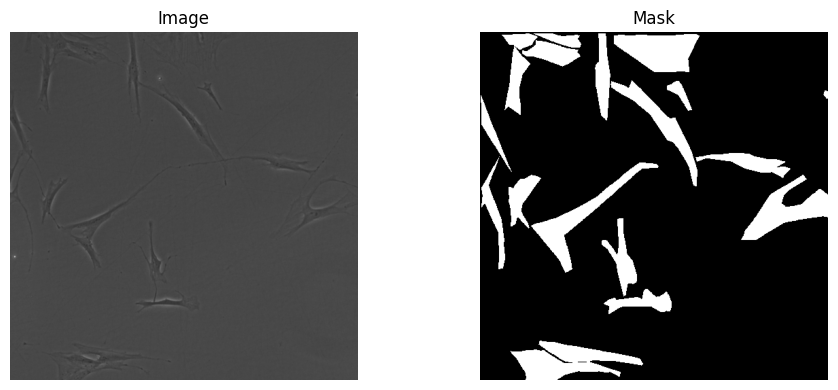


Image tensor shape : torch.Size([3, 512, 512])
Image dtype        : torch.float32
Image value range  : [-1.313, 1.751]  (setelah normalisasi)
Mask tensor shape  : torch.Size([1, 512, 512])
Mask unique values : [0.0, 1.0]

✅ Preprocessing verification passed: /255.0 -> Normalize(ImageNet mean/std)


In [10]:
# =====================================================================
# 7) DataLoaders - Optimized for Dual GPU
# =====================================================================
# [R5] PyTorch DataLoader docs:
#   https://pytorch.org/docs/stable/data.html
#
# pin_memory=True:
#   "Enabling pinned memory allows the host-to-device data transfer to be
#    asynchronous." - PyTorch Docs
#   Efektif karena transfer CPU->GPU via DMA (tanpa blocking CPU).
#
# drop_last=True (train_loader):
#   WAJIB untuk DataParallel [R5]: saat batch size < NUM_GPUS,
#   DataParallel tidak bisa scatter batch ke semua GPU -> RuntimeError.
#   drop_last membuang batch terakhir yang tidak penuh.
# =====================================================================

# SegmentationDataset() menerapkan rescale [0,1] + normalisasi ImageNet [R3].
# Preprocessing AKTIF untuk semua sample train dan val.
print("=== Train Dataset ===")
train_dataset = SegmentationDataset(train_pairs, task_type=TASK_TYPE)
print("=== Val Dataset ===")
valid_dataset = SegmentationDataset(val_pairs,   task_type=TASK_TYPE)

# Hitung num_workers optimal: ~4 per GPU, dibatasi CPU count
# Ref: https://pytorch.org/docs/stable/data.html#single-and-multi-process-data-loading
NUM_WORKERS = min(4 * max(1, NUM_GPUS), os.cpu_count() or 4)
_pin_mem    = NUM_GPUS > 0      # pin_memory hanya berguna saat ada GPU
_persist    = NUM_WORKERS > 0   # persistent_workers butuh num_workers > 0

print(f"num_workers : {NUM_WORKERS}")
print(f"pin_memory  : {_pin_mem}")

train_loader = DataLoader(
    train_dataset,
    batch_size         = BATCH_SIZE,   # total batch; DataParallel bagi ke tiap GPU
    shuffle            = True,
    num_workers        = NUM_WORKERS,
    pin_memory         = _pin_mem,
    persistent_workers = _persist,     # hindari fork/join overhead antar epoch
    prefetch_factor    = 2 if _persist else None,  # prefetch 2 batch per worker
    drop_last          = True,         # WAJIB untuk DataParallel [R5]
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size         = BATCH_SIZE,
    shuffle            = False,
    num_workers        = NUM_WORKERS,
    pin_memory         = _pin_mem,
    persistent_workers = _persist,
    prefetch_factor    = 2 if _persist else None,
    drop_last          = False,        # evaluasi SEMUA sampel validasi
)

print(f"Train batches : {len(train_loader)} (drop_last dari {len(train_dataset)} sampel)")
print(f"Val batches   : {len(valid_loader)} ({len(valid_dataset)} sampel)")
show_sample(train_dataset, 0)

# =====================================================================
# Verifikasi Sample Tensor: rescale [0,1] + normalisasi ImageNet [R3]
# =====================================================================
_sample_img, _sample_mask = train_dataset[0]
print(f"\nImage tensor shape : {_sample_img.shape}")
print(f"Image dtype        : {_sample_img.dtype}")
print(f"Image value range  : [{_sample_img.min():.3f}, {_sample_img.max():.3f}]  (setelah normalisasi)")
print(f"Mask tensor shape  : {_sample_mask.shape}")
print(f"Mask unique values : {_sample_mask.unique().tolist()}")
print("\n✅ Preprocessing verification passed: /255.0 -> Normalize(ImageNet mean/std)")

In [11]:
img, mask = train_dataset[0]
print(img.shape)
print(mask.shape)

torch.Size([3, 512, 512])
torch.Size([1, 512, 512])


## Bagian 8 -- Model, Loss, Optimizer, Scheduler

### Arsitektur: U-Net + Encoder ResNet50

**U-Net [R2]** -- Ronneberger et al., MICCAI 2015:
> *"The architecture consists of a contracting path (encoder) to capture context
> and a symmetric expanding path (decoder) that enables precise localization."*

Skip connections menghubungkan tiap level encoder ke decoder yang sesuai,
memungkinkan model mempertahankan detail spasial sekaligus konteks semantik.

**ResNet50 Encoder [R1][R3]** -- He et al., CVPR 2016:
> *"We present a residual learning framework to ease the training of networks
> that are substantially deeper than those used previously."*

Struktur ResNet50 sebagai encoder (output channel per stage):
```
Input (3, H, W)
  -> conv1       : (64,  H/2,  W/2)   [stem]
  -> layer1 (x3): (256,  H/4,  W/4)  [Bottleneck blocks]
  -> layer2 (x4): (512,  H/8,  W/8)
  -> layer3 (x6): (1024, H/16, W/16)
  -> layer4 (x3): (2048, H/32, W/32)  [bottleneck]
```

SMP [R4] mengekstrak output tiap stage sebagai skip connections ke decoder U-Net.

> **Mengapa pretrained penting?** [R1][R3]
> ResNet50 dari scratch butuh 100+ epoch untuk konvergen.
> Dengan ImageNet weights, encoder sudah punya representasi fitur visual yang kuat
> (tepi, sudut, tekstur, objek parsial), sehingga hanya decoder yang perlu dilatih intensif.

### Loss: BCE + Dice [R8]

Kombinasi **BCEWithLogitsLoss + Dice Loss** [R8]:
- BCE: gradien per-pixel stabil di awal training
- Dice: `1 - DSC = 1 - 2|XnY|/(|X|+|Y|)` - cocok untuk class imbalance [R8]

### Optimizer: AdamW [R6] | Scheduler: CosineAnnealingLR | AMP: GradScaler [R7]

In [12]:
# =====================================================================
# 8) Model + DataParallel + Loss + Optimizer + Scheduler
# =====================================================================

# ---- Model: smp.Unet dengan encoder ResNet50 ----
# [R4] segmentation_models_pytorch.Unet:
#   "The main components of U-Net are encoder (backbone, contracting path)
#    and decoder (expanding path)."
#   https://smp.readthedocs.io/en/latest/models.html#unet
#
# [R1] He et al. (2016): encoder_name="resnet50"
#   50-layer Deep Residual Network dengan Bottleneck blocks
#   encoder_channels (SMP): [3, 64, 256, 512, 1024, 2048]
#
# [R3] TorchVision ResNet50: encoder_weights="imagenet"
#   Pretrained weights ImageNet — normalisasi wajib, ditangani
#   otomatis oleh SegmentationDataset via smp.encoders.get_preprocessing_params() [R4]
#   Ref: https://pytorch.org/vision/stable/models/generated/torchvision.models.resnet50.html
#
# activation=None: output berupa logits mentah
#   Binary     -> sigmoid di loss (BCEWithLogitsLoss)
#   Multiclass -> softmax/argmax di luar model
model = smp.Unet(
    encoder_name    = ENCODER_NAME,      # "resnet50" [R1][R3]
    encoder_weights = ENCODER_WEIGHTS,   # "imagenet" - pretrained ImageNet [R3]
    in_channels     = IN_CHANNELS,       # 3 channel RGB
    classes         = NUM_CLASSES,       # 1 (binary) atau N (multiclass)
    activation      = None,              # output = logits
).to(DEVICE)                             # WAJIB sebelum DataParallel [R5]

# ---- DataParallel Wrapping ----
# [R5] PyTorch DataParallel:
#   "Before running, model parameters MUST be on device_ids[0]."
#   -> Wajib .to(DEVICE) dulu, baru bungkus DataParallel.
#
# PENTING saat save/load checkpoint:
#   SAVE: gunakan model.module.state_dict() (bukan model.state_dict())
#         agar checkpoint portabel tanpa DataParallel.
#   LOAD: load ke model biasa (bukan DataParallel) terlebih dahulu.
#   Ref: https://pytorch.org/tutorials/beginner/saving_loading_models.html
#        #saving-torch-nn-dataparallel-models
if NUM_GPUS > 1:
    model = nn.DataParallel(model, device_ids=list(range(NUM_GPUS)))
    print(f"[DataParallel] Aktif: {NUM_GPUS} GPU {list(range(NUM_GPUS))}")
    print(f"[DataParallel] Batch total: {BATCH_SIZE} ({BATCH_SIZE_PER_GPU}/GPU x {NUM_GPUS})")
else:
    print(f"[Single GPU] {DEVICE}")

# Info encoder ResNet50 [R1][R4]
_enc = model.module.encoder if isinstance(model, nn.DataParallel) else model.encoder
print(f"Encoder     : {_enc.__class__.__name__}  [R1]")
print(f"Enc channels: {_enc.out_channels}  [R1] (tiap stage ResNet50)")

# ---- Optimizer: AdamW dengan Differential Learning Rate [R6] ----
# Loshchilov & Hutter (2019): AdamW memisahkan weight decay dari gradient [R6]
#
# Differential LR — dua param group dengan lr berbeda:
#   encoder (pretrained ImageNet [R3]): lr kecil agar bobot pretrained tidak overwrite
#   decoder (random init [R2])        : lr lebih besar agar konvergen dari scratch
# Ini adalah praktik umum fine-tuning; tidak ada dokumentasi resmi yang
# menetapkan nilai spesifik. Sesuaikan berdasarkan monitoring val_dice.
# Ref optimizer: https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html

_raw = model.module if isinstance(model, nn.DataParallel) else model
_enc_params = list(_raw.encoder.parameters())
_dec_params = [p for p in _raw.parameters()
               if not any(p is ep for ep in _enc_params)]

optimizer = torch.optim.AdamW([
    {"params": _enc_params, "lr": LEARNING_RATE, "weight_decay": WEIGHT_DECAY},  # encoder: lr kecil [R1]
    {"params": _dec_params, "lr": LR_DECODER,    "weight_decay": WEIGHT_DECAY},  # decoder: lr besar [R2]
], betas=(0.9, 0.999))
print(f"Differential LR: encoder={LEARNING_RATE:.0e}, decoder={LR_DECODER:.0e}  [R6]")

# ---- Scheduler: CosineAnnealingLR ----
# Loshchilov & Hutter (2017) - "SGDR: SGD with Warm Restarts"
# lr menurun dari LEARNING_RATE ke ETA_MIN mengikuti kurva cosinus selama T_max epoch
# Formula: lr_t = eta_min + 0.5*(lr_max-eta_min)*(1 + cos(pi*t/T_max))
# Ref: https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=ETA_MIN
)
print(f"CosineAnnealingLR: T_max={EPOCHS}, eta_min={ETA_MIN}")

# ---- GradScaler: AMP [R7] ----
# Micikevicius et al. (2018): scale loss sebelum backward untuk cegah
# underflow gradient dalam FP16.
# Ref: https://pytorch.org/docs/stable/amp.html
# torch.amp.GradScaler (PyTorch >= 2.0) - ganti torch.cuda.amp.GradScaler [R7]
# Perubahan API: GradScaler sekarang menerima device sebagai arg pertama.
# 'cuda' = training di GPU; ganti 'cpu' untuk CPU (AMP tidak aktif di CPU).
# Ref: https://pytorch.org/docs/stable/amp.html#torch.amp.GradScaler
scaler = GradScaler('cuda', enabled=AMP)   # PyTorch >= 2.0 [R7]


# =====================================================================
# Loss Functions [R8]
# =====================================================================
# [R8] Milletari et al. (2016): V-Net memperkenalkan Dice Loss
#   Dice Similarity Coefficient: DSC = 2|XnY| / (|X|+|Y|)  in [0, 1]
#   Dice Loss = 1 - DSC
#   Cocok untuk segmentasi dengan class imbalance (foreground << background)
# Kombinasi BCE + Dice umum dipakai (lihat nnU-Net, Isensee et al. 2021)

def dice_loss_binary(logits, targets, eps=1e-7):
    # Dice Loss binary. Input: logits (B,1,H,W), targets (B,1,H,W) float {0,1} [R8]
    probs        = torch.sigmoid(logits)        # logits -> probabilitas [0,1]
    targets      = targets.float()
    dims         = (0, 2, 3)                    # reduce batch+spatial; pertahankan channel
    intersection = (probs * targets).sum(dims)
    denom        = probs.sum(dims) + targets.sum(dims)
    return 1.0 - ((2.0 * intersection + eps) / (denom + eps)).mean()

def dice_score_binary(logits, targets, eps=1e-7):
    # DSC binary dengan threshold 0.5 [R8]
    probs        = (torch.sigmoid(logits) > 0.5).float()
    targets      = targets.float()
    dims         = (0, 2, 3)
    intersection = (probs * targets).sum(dims)
    denom        = probs.sum(dims) + targets.sum(dims)
    return ((2.0 * intersection + eps) / (denom + eps)).mean().item()

def iou_score_binary(logits, targets, eps=1e-7):
    # Intersection over Union / Jaccard Index untuk binary segmentasi
    probs        = (torch.sigmoid(logits) > 0.5).float()
    targets      = targets.float()
    dims         = (0, 2, 3)
    intersection = (probs * targets).sum(dims)
    union        = probs.sum(dims) + targets.sum(dims) - intersection
    return ((intersection + eps) / (union + eps)).mean().item()

def dice_loss_multiclass(logits, targets, eps=1e-7):
    # Dice Loss multiclass via one-hot encoding. targets: LongTensor (B,H,W) [R8]
    probs        = torch.softmax(logits, dim=1)
    num_classes  = logits.shape[1]
    # One-hot: (B,H,W) -> (B,C,H,W)
    targets_oh   = F.one_hot(targets.long(), num_classes).permute(0,3,1,2).float()
    dims         = (0, 2, 3)
    intersection = (probs * targets_oh).sum(dims)
    denom        = probs.sum(dims) + targets_oh.sum(dims)
    return 1.0 - ((2.0 * intersection + eps) / (denom + eps)).mean()

def dice_score_multiclass(logits, targets, eps=1e-7):
    # DSC multiclass (mean over all classes) [R8]
    preds       = torch.argmax(logits, dim=1)
    num_classes = logits.shape[1]
    preds_oh    = F.one_hot(preds.long(),    num_classes).permute(0,3,1,2).float()
    targets_oh  = F.one_hot(targets.long(),  num_classes).permute(0,3,1,2).float()
    dims        = (0, 2, 3)
    intersection = (preds_oh * targets_oh).sum(dims)
    denom        = preds_oh.sum(dims) + targets_oh.sum(dims)
    return ((2.0 * intersection + eps) / (denom + eps)).mean().item()

def iou_score_multiclass(logits, targets, eps=1e-7):
    # IoU multiclass (mean Jaccard Index) [R8]
    preds       = torch.argmax(logits, dim=1)
    num_classes = logits.shape[1]
    preds_oh    = F.one_hot(preds.long(),   num_classes).permute(0,3,1,2).float()
    targets_oh  = F.one_hot(targets.long(), num_classes).permute(0,3,1,2).float()
    dims        = (0, 2, 3)
    intersection = (preds_oh * targets_oh).sum(dims)
    union        = preds_oh.sum(dims) + targets_oh.sum(dims) - intersection
    return ((intersection + eps) / (union + eps)).mean().item()

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

[DataParallel] Aktif: 2 GPU [0, 1]
[DataParallel] Batch total: 4 (2/GPU x 2)
Encoder     : ResNetEncoder  [R1]
Enc channels: [3, 64, 256, 512, 1024, 2048]  [R1] (tiap stage ResNet50)
Differential LR: encoder=1e-04, decoder=1e-03  [R6]
CosineAnnealingLR: T_max=100, eta_min=1e-06


## Bagian 9 -- Fungsi Train & Validate

Setiap epoch terdiri dari dua phase:

**`train_one_epoch`:** forward + backward + optimizer step (mode `.train()`)
**`validate`:** hanya forward (mode `.eval()`, tanpa gradient)

### Alur per batch (training)

```
1. Transfer data ke DEVICE (non_blocking=True untuk async H2D copy)
2. zero_grad(set_to_none=True)  -- lebih efisien dari fill-zero [R5]
3. autocast('cuda', enabled=AMP)  -- pilih FP16/FP32 per-operasi (PyTorch >= 2.0) [R7]
4. model(images)                -- DataParallel scatter ke GPU otomatis [R5]
5. hitung loss (BCE + Dice)     -- [R8]
6. scaler.scale(loss).backward()-- scaled gradient untuk FP16 [R7]
7. scaler.step(optimizer)       -- unscale + AdamW step [R6]
8. scaler.update()              -- update GradScaler factor
```

### AMP Benefit [R7]
- **~2-3x speedup** pada GPU Tensor Core (T4 mendukung FP16 Tensor Core)
- **~50% VRAM lebih hemat** dibanding FP32 penuh

In [13]:
# =====================================================================
# 9) Train & Validate Functions
# =====================================================================

writer            = SummaryWriter(log_dir=str(LOG_DIR))
history_rows      = []
best_val_dice     = -1.0


def forward_loss_and_metrics(logits, masks):
    # Hitung combined loss (BCE + Dice) dan metrik (Dice, IoU)
    # Binary  : BCEWithLogitsLoss + DiceLoss [R8]
    #           BCEWithLogitsLoss = sigmoid + BCE, numerically stable
    #           Ref: https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html
    # Multiclass: CrossEntropyLoss + DiceLoss [R8]
    #           CrossEntropyLoss = log-softmax + NLLLoss (expects LongTensor target)
    if TASK_TYPE == "binary":
        loss = (F.binary_cross_entropy_with_logits(logits, masks.float())
                + dice_loss_binary(logits, masks))
        dice = dice_score_binary(logits, masks)
        iou  = iou_score_binary(logits, masks)
    else:
        loss = (F.cross_entropy(logits, masks.long())
                + dice_loss_multiclass(logits, masks))
        dice = dice_score_multiclass(logits, masks)
        iou  = iou_score_multiclass(logits, masks)
    return loss, dice, iou


def train_one_epoch(model, loader):
    # Training satu epoch dengan AMP [R7] dan DataParallel support [R5]
    model.train()
    running_loss = running_dice = running_iou = 0.0

    for images, masks in loader:
        # non_blocking=True: async H2D transfer (efektif karena pin_memory=True)
        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE, non_blocking=True)

        # set_to_none=True: gradient tensor di-set None (bukan fill-zero) - lebih efisien [R5]
        # Ref: https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.zero_grad.html
        optimizer.zero_grad(set_to_none=True)

        # autocast: FP16 untuk Conv/Linear/MatMul, FP32 untuk loss [R7]
        # Micikevicius et al. (2018): "operations that are safe to run in FP16"
        with autocast('cuda', enabled=AMP):   # device arg wajib di PyTorch >= 2.0 [R7]
            logits = model(images)         # DataParallel scatter+gather otomatis [R5]
            loss, dice, iou = forward_loss_and_metrics(logits, masks)

        # GradScaler: scale(loss) -> backward() -> unscale() -> step() [R7]
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        running_dice += dice
        running_iou  += iou

    n = max(1, len(loader))
    return {"loss": running_loss/n, "dice": running_dice/n, "iou": running_iou/n}


@torch.no_grad()
def validate(model, loader):
    # Validasi satu epoch
    # @torch.no_grad(): matikan autograd - hemat VRAM + lebih cepat
    # .eval(): matikan Dropout + set BatchNorm ke inference mode
    # Ref: https://pytorch.org/docs/stable/generated/torch.nn.Module.eval.html
    model.eval()
    running_loss = running_dice = running_iou = 0.0

    for images, masks in loader:
        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE, non_blocking=True)
        logits = model(images)
        loss, dice, iou = forward_loss_and_metrics(logits, masks)
        running_loss += loss.item()
        running_dice += dice
        running_iou  += iou

    n = max(1, len(loader))
    return {"loss": running_loss/n, "dice": running_dice/n, "iou": running_iou/n}

## Bagian 10 -- Training Loop

Loop utama dengan:
- **Checkpoint `best.pt`**: disimpan saat val dice baru terbaik
- **Checkpoint `last.pt`**: disimpan setiap epoch (untuk resume)
- **TensorBoard + CSV**: semua metrik dilog per epoch

### Checkpoint DataParallel [R5]

Dari PyTorch tutorial:
> *"To save a DataParallel model generically, save the `model.module.state_dict()`.
> This way, you have the flexibility to load the model any way you want to any device
> you want."*
>
> https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-torch-nn-dataparallel-models

Dengan menyimpan `model.module.state_dict()`, checkpoint portabel:
tidak perlu DataParallel saat di-load untuk inference.


🚀 Mulai training...
Ep 001/100 | train L=0.6366 D=0.7997 IoU=0.6781 | val L=0.4105 D=0.8516 IoU=0.7437 | lr=1.00e-04 | 111.6s *BEST*
Ep 002/100 | train L=0.3559 D=0.8808 IoU=0.7878 | val L=0.3594 D=0.8665 IoU=0.7663 | lr=9.99e-05 | 85.9s *BEST*
Ep 003/100 | train L=0.3019 D=0.8939 IoU=0.8087 | val L=0.2883 D=0.8931 IoU=0.8085 | lr=9.98e-05 | 85.1s *BEST*
Ep 004/100 | train L=0.2802 D=0.8999 IoU=0.8186 | val L=0.2971 D=0.8880 IoU=0.8005 | lr=9.96e-05 | 86.6s
Ep 005/100 | train L=0.2697 D=0.9032 IoU=0.8240 | val L=0.2946 D=0.8904 IoU=0.8046 | lr=9.94e-05 | 82.5s
Ep 006/100 | train L=0.2570 D=0.9056 IoU=0.8282 | val L=0.2794 D=0.8967 IoU=0.8140 | lr=9.91e-05 | 84.4s *BEST*
Ep 007/100 | train L=0.2517 D=0.9079 IoU=0.8318 | val L=0.2850 D=0.8943 IoU=0.8101 | lr=9.88e-05 | 85.4s
Ep 008/100 | train L=0.2391 D=0.9131 IoU=0.8404 | val L=0.2761 D=0.8974 IoU=0.8151 | lr=9.84e-05 | 83.1s *BEST*
Ep 009/100 | train L=0.2319 D=0.9142 IoU=0.8425 | val L=0.2954 D=0.8929 IoU=0.8080 | lr=9.80e-05 | 83.7

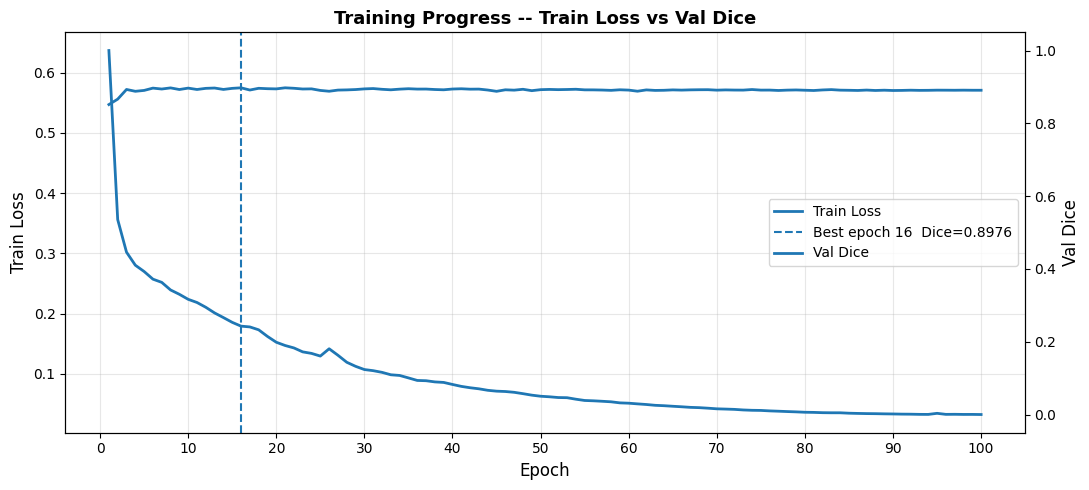

✅ Grafik disimpan ke: resnet50_unet_artifacts_scale05/train_val_curve.png
✅ Best epoch: 16 | Best Val Dice: 0.8976

📌 Riwayat training terakhir:
    epoch  train_loss  train_dice  train_iou  val_loss  val_dice   val_iou  \
95     96    0.032552    0.988190   0.976659  0.548023  0.891054  0.804779   
96     97    0.032662    0.988119   0.976520  0.542855  0.890890  0.804520   
97     98    0.032453    0.988149   0.976581  0.553518  0.891141  0.804943   
98     99    0.032483    0.988188   0.976654  0.542158  0.890902  0.804536   
99    100    0.032293    0.988281   0.976836  0.556431  0.890869  0.804473   

          lr    seconds  
95  0.000001  83.001220  
96  0.000001  83.111419  
97  0.000001  86.018137  
98  0.000001  85.500314  
99  0.000001  86.523983  


In [14]:
import os
import gc
import time
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ============================================================
# Helper
# ============================================================
def get_model_state_dict(model):
    """Aman untuk model biasa maupun DataParallel."""
    return model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()

def save_training_curve(history_df, save_path):
    """Simpan grafik train loss vs val dice seperti contoh Anda."""
    if history_df.empty:
        print("⚠️ History kosong, grafik tidak dibuat.")
        return

    ep = history_df["epoch"].values
    train_loss = history_df["train_loss"].values
    val_dice = history_df["val_dice"].values

    best_idx = int(np.argmax(val_dice))
    best_epoch = ep[best_idx]
    best_dice = val_dice[best_idx]

    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax2 = ax1.twinx()

    ax1.plot(ep, train_loss, lw=2, label="Train Loss")
    ax2.plot(ep, val_dice, lw=2, label="Val Dice")

    ax2.set_ylim(-0.05, 1.05)
    ax1.axvline(
        best_epoch,
        ls="--",
        lw=1.5,
        label=f"Best epoch {best_epoch}  Dice={best_dice:.4f}"
    )

    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Train Loss", fontsize=12)
    ax2.set_ylabel("Val Dice", fontsize=12)

    ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))

    lines = ax1.get_lines() + ax2.get_lines()
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="center right", fontsize=10)

    plt.title(
        "Training Progress -- Train Loss vs Val Dice",
        fontsize=13,
        fontweight="bold"
    )
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"✅ Grafik disimpan ke: {save_path}")
    print(f"✅ Best epoch: {best_epoch} | Best Val Dice: {best_dice:.4f}")

# ============================================================
# Training loop
# ============================================================
history_rows = []
best_val_dice = -1.0

print("\n🚀 Mulai training...")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # Train & validation step
    train_logs = train_one_epoch(model, train_loader)
    valid_logs = validate(model, valid_loader)

    # Update scheduler
    scheduler.step()

    # Catat hasil epoch
    row = {
        "epoch": epoch,
        "train_loss": float(train_logs["loss"]),
        "train_dice": float(train_logs["dice"]),
        "train_iou": float(train_logs["iou"]),
        "val_loss": float(valid_logs["loss"]),
        "val_dice": float(valid_logs["dice"]),
        "val_iou": float(valid_logs["iou"]),
        "lr": float(optimizer.param_groups[0]["lr"]),
        "seconds": float(time.time() - t0),
    }
    history_rows.append(row)

    # Simpan history tiap epoch
    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(CSV_LOG_PATH, index=False)

    # TensorBoard logging
    writer.add_scalar("loss/train", row["train_loss"], epoch)
    writer.add_scalar("loss/val", row["val_loss"], epoch)
    writer.add_scalar("dice/train", row["train_dice"], epoch)
    writer.add_scalar("dice/val", row["val_dice"], epoch)
    writer.add_scalar("iou/train", row["train_iou"], epoch)
    writer.add_scalar("iou/val", row["val_iou"], epoch)
    writer.add_scalar("lr", row["lr"], epoch)

    # Cek apakah ini best model
    is_best = row["val_dice"] > best_val_dice
    if is_best:
        best_val_dice = row["val_dice"]

    # Checkpoint
    _ckpt = {
        "epoch": epoch,
        "model_state_dict": get_model_state_dict(model),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_dice": best_val_dice,
        "config": {
            "task_type": TASK_TYPE,
            "encoder_name": ENCODER_NAME,
            "encoder_weights": ENCODER_WEIGHTS,
            "num_classes": NUM_CLASSES,
            "in_channels": IN_CHANNELS,
            "input_h": INPUT_H,
            "input_w": INPUT_W,
            "scale": SCALE,
        },
    }

    if is_best:
        torch.save(_ckpt, BEST_CKPT_PATH)

    torch.save(_ckpt, LAST_CKPT_PATH)

    # Logging terminal
    flag = " *BEST*" if is_best else ""
    print(
        f"Ep {epoch:03d}/{EPOCHS} | "
        f"train L={row['train_loss']:.4f} D={row['train_dice']:.4f} IoU={row['train_iou']:.4f} | "
        f"val L={row['val_loss']:.4f} D={row['val_dice']:.4f} IoU={row['val_iou']:.4f} | "
        f"lr={row['lr']:.2e} | {row['seconds']:.1f}s{flag}"
    )

    # Bersihkan memori
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

writer.close()

# ============================================================
# Ringkasan akhir
# ============================================================
history_df = pd.DataFrame(history_rows)
history_df.to_csv(CSV_LOG_PATH, index=False)

print(f"\nBest val Dice  : {best_val_dice:.4f}")
print(f"CSV log        : {CSV_LOG_PATH}")
print(f"Best checkpoint: {BEST_CKPT_PATH}")
print(f"Last checkpoint: {LAST_CKPT_PATH}")
 
# Simpan plot training
PLOT_PATH = os.path.join(os.path.dirname(CSV_LOG_PATH), "train_val_curve.png")
save_training_curve(history_df, PLOT_PATH)

# Tampilkan beberapa baris terakhir supaya progresnya kelihatan
print("\n📌 Riwayat training terakhir:")
print(history_df.tail())

## Bagian 11 -- Plot Training Curves

Visualisasi tiga panel:
1. **Loss** (train vs. val) -- pantau overfitting
2. **Dice Score** (train vs. val) -- metrik segmentasi utama [R2][R8]
3. **Learning Rate** -- verifikasi cosine annealing schedule berjalan benar

,epoch,train_loss,train_dice,train_iou,val_loss,val_dice,val_iou,lr,seconds
0,1,0.636648,0.799653,0.678138,0.410491,0.851562,0.743658,0.000100,111.578230
1,2,0.355942,0.880752,0.787767,0.359401,0.866472,0.766331,0.000100,85.937191
2,3,0.301867,0.893853,0.808679,0.288286,0.893057,0.808472,0.000100,85.104104
3,4,0.280215,0.899853,0.818560,0.297061,0.888003,0.800520,0.000100,86.560910
4,5,0.269738,0.903172,0.823955,0.294595,0.890436,0.804583,0.000099,82.543706


CSV_LOG_PATH : resnet50_unet_artifacts_scale05/history.csv
Exists       : True
Size (bytes) : 15806
Shape : (100, 9)
   epoch  train_loss  train_dice  train_iou  val_loss  val_dice   val_iou  \
0      1    0.636648    0.799653   0.678138  0.410491  0.851562  0.743658   
1      2    0.355942    0.880752   0.787767  0.359401  0.866472  0.766331   
2      3    0.301867    0.893853   0.808679  0.288286  0.893057  0.808472   
3      4    0.280215    0.899853   0.818560  0.297061  0.888003  0.800520   
4      5    0.269738    0.903172   0.823955  0.294595  0.890436  0.804583   

         lr     seconds  
0  0.000100  111.578230  
1  0.000100   85.937191  
2  0.000100   85.104104  
3  0.000100   86.560910  
4  0.000099   82.543706  
    epoch  train_loss  train_dice  train_iou  val_loss  val_dice   val_iou  \
95     96    0.032552    0.988190   0.976659  0.548023  0.891054  0.804779   
96     97    0.032662    0.988119   0.976520  0.542855  0.890890  0.804520   
97     98    0.032453    0.988

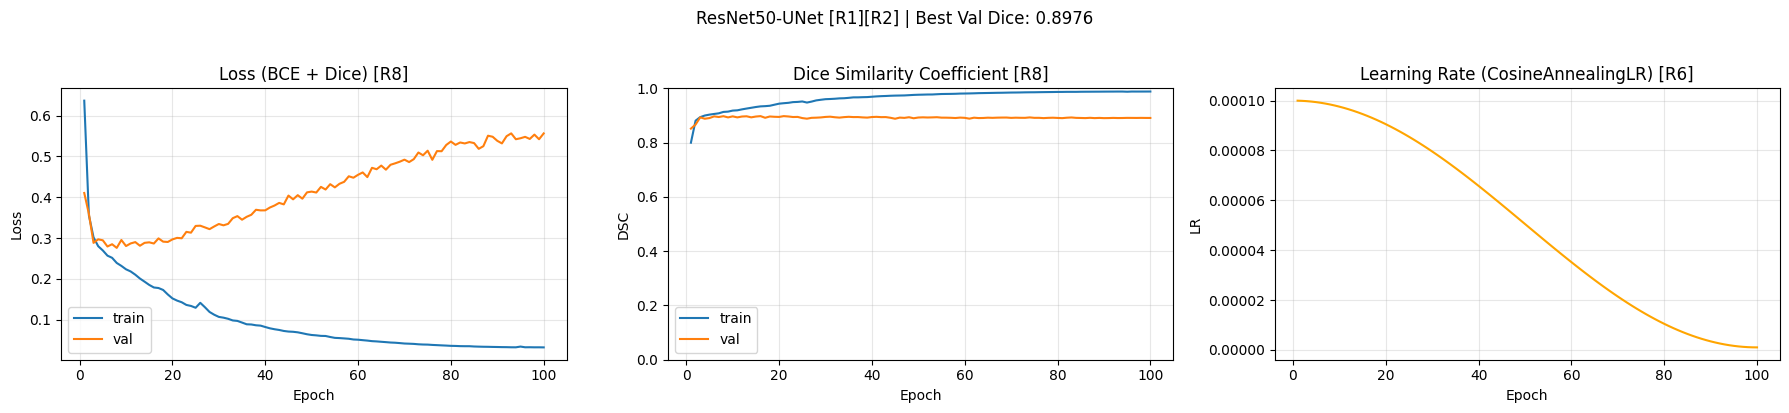

In [15]:
# =====================================================================
# 11) Plot Training Curves
# =====================================================================
history = pd.read_csv(CSV_LOG_PATH) 
display(history.head())
import os 

print("CSV_LOG_PATH :", CSV_LOG_PATH)
print("Exists       :", os.path.exists(CSV_LOG_PATH))
print("Size (bytes) :", os.path.getsize(CSV_LOG_PATH))

history = pd.read_csv(CSV_LOG_PATH)
 
print("Shape :", history.shape)
print(history.head())
print(history.tail())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history["epoch"], history["train_loss"], label="train", lw=1.5)
axes[0].plot(history["epoch"], history["val_loss"],   label="val",   lw=1.5)
axes[0].set_title("Loss (BCE + Dice) [R8]")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)
    
# Dice Similarity Coefficient [R2][R8]
axes[1].plot(history["epoch"], history["train_dice"], label="train", lw=1.5)
axes[1].plot(history["epoch"], history["val_dice"],   label="val",   lw=1.5)
axes[1].set_title("Dice Similarity Coefficient [R8]")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("DSC")
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

# Learning Rate -- Cosine Annealing
axes[2].plot(history["epoch"], history["lr"], color="orange", lw=1.5)
axes[2].set_title("Learning Rate (CosineAnnealingLR) [R6]")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR")  
axes[2].grid(alpha=0.3)

plt.suptitle(f"ResNet50-UNet [R1][R2] | Best Val Dice: {best_val_dice:.4f}", y=1.02)
plt.tight_layout(); plt.show()

## Bagian 12 -- Load Best Checkpoint untuk Inference

Karena checkpoint disimpan dari `model.module.state_dict()`, model baru dibuat
**tanpa** DataParallel terlebih dahulu sebelum state_dict di-load.

Dari PyTorch tutorial [R5]:
> *"If a model is saved from a `DataParallel` module, the `state_dict()` keys will
> have `module.` prefix. To avoid confusion when loading checkpoints, save from
> `model.module`."*

Checkpoint yang disimpan dengan cara ini portabel ke:
- Kaggle (2 GPU, 1 GPU, atau CPU)
- Lingkungan inference manapun tanpa perlu DataParallel

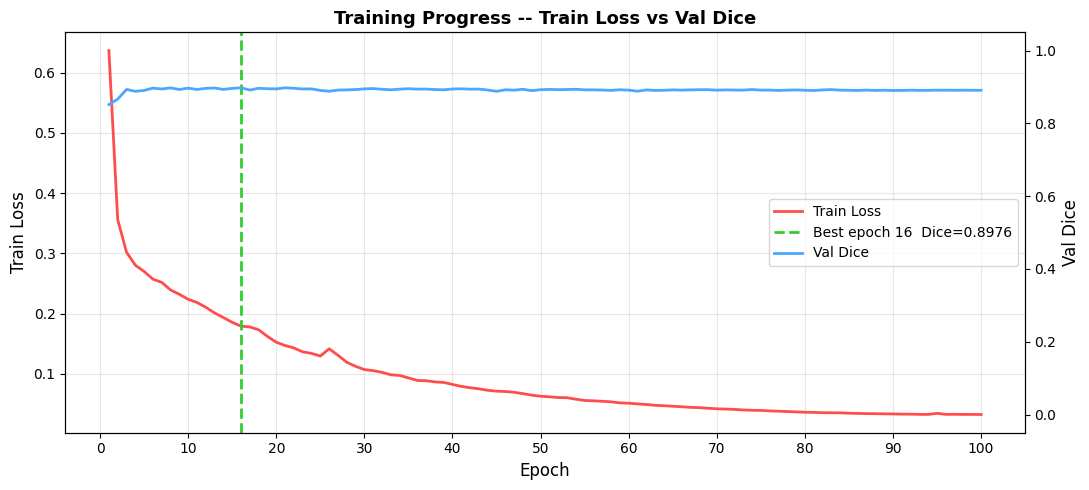

Best epoch: 16 | Best Val Dice: 0.8976


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ============================================================
# Ambil history yang sudah ada, tanpa training ulang
# ============================================================
if "history_df" not in globals() or history_df is None or history_df.empty:
    if "CSV_LOG_PATH" not in globals():
        raise ValueError("history_df dan CSV_LOG_PATH tidak ditemukan.")
    history_df = pd.read_csv(CSV_LOG_PATH)

# Pastikan kolom yang dibutuhkan ada
required_cols = ["epoch", "train_loss", "val_dice"]
missing = [c for c in required_cols if c not in history_df.columns]
if missing:
    raise ValueError(f"Kolom berikut tidak ada di history_df: {missing}")

ep = history_df["epoch"].to_numpy()
train_loss = history_df["train_loss"].to_numpy()
val_dice = history_df["val_dice"].to_numpy()

best_idx = int(np.argmax(val_dice))
best_epoch = int(ep[best_idx])
best_dice = float(val_dice[best_idx])

# ============================================================
# Plot
# ============================================================
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

# Train Loss : merah terang
line1, = ax1.plot(
    ep,
    train_loss,
    lw=2,
    color="#FF4D4D",
    label="Train Loss"
)

# Best Epoch : hijau terang
line2 = ax1.axvline(
    best_epoch,
    ls="--",
    lw=2,
    color="#32CD32",
    label=f"Best epoch {best_epoch}  Dice={best_dice:.4f}"
)

# Val Dice : biru terang
line3, = ax2.plot(
    ep,
    val_dice,
    lw=2,
    color="#4DA6FF",
    label="Val Dice"
)

ax1.set_title("Training Progress -- Train Loss vs Val Dice", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Train Loss", fontsize=12)
ax2.set_ylabel("Val Dice", fontsize=12)

ax2.set_ylim(-0.05, 1.05)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax1.grid(alpha=0.3)

# Legend urutan sesuai yang Anda mau
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="center right", fontsize=10)

plt.tight_layout()
plt.show()

print(f"Best epoch: {best_epoch} | Best Val Dice: {best_dice:.4f}")

In [16]:
# =====================================================================
# 12) Load Best Checkpoint
# =====================================================================
# [R5] Loading state_dict dari DataParallel model: 
#   Ref: https://pytorch.org/tutorials/beginner/saving_loading_models.html
#        #saving-torch-nn-dataparallel-models
#
# [R3] TorchVision ResNet50: recreate model dengan konfigurasi identik
#      agar state_dict key names dan shapes cocok
# =====================================================================

best_ckpt = torch.load(BEST_CKPT_PATH, map_location=DEVICE)

# Recreate model bersih TANPA DataParallel [R3][R4]
# Konfigurasi harus identik dengan saat training
_cfg         = best_ckpt.get("config", {})
_enc_name    = _cfg.get("encoder_name",    ENCODER_NAME)
_enc_weights = _cfg.get("encoder_weights", ENCODER_WEIGHTS)
_n_classes   = _cfg.get("num_classes",     NUM_CLASSES)
_in_ch       = _cfg.get("in_channels",     IN_CHANNELS)

# Buat model baru: smp.Unet + encoder ResNet50 [R1][R2][R4]
model_eval = smp.Unet(
    encoder_name    = _enc_name,     # "resnet50" [R1]
    encoder_weights = _enc_weights,  # "imagenet" dari checkpoint config [R3]
    in_channels     = _in_ch,
    classes         = _n_classes,
    activation      = None,
).to(DEVICE)

# Load state_dict yang disimpan dari model.module (tidak ada prefix "module.") [R5]
model_eval.load_state_dict(best_ckpt["model_state_dict"])
model_eval.eval()   # matikan Dropout + set BatchNorm ke inference mode

print(f"Checkpoint epoch : {best_ckpt['epoch']}")
print(f"Best val Dice    : {best_ckpt['best_val_dice']:.4f}")
print(f"Encoder          : {_enc_name}  [R1] He et al. 2016")
print(f"Encoder weights  : {_enc_weights}  [R3] TorchVision API")
print(f"Task type        : {_cfg.get('task_type', TASK_TYPE)}")
print("Model siap untuk inference.")

Checkpoint epoch : 16
Best val Dice    : 0.8976
Encoder          : resnet50  [R1] He et al. 2016
Encoder weights  : imagenet  [R3] TorchVision API
Task type        : binary
Model siap untuk inference.


,epoch,train_loss,train_dice,train_iou,val_loss,val_dice,val_iou,lr,seconds
0,1,0.636648,0.799653,0.678138,0.410491,0.851562,0.743658,0.000100,111.578230
1,2,0.355942,0.880752,0.787767,0.359401,0.866472,0.766331,0.000100,85.937191
2,3,0.301867,0.893853,0.808679,0.288286,0.893057,0.808472,0.000100,85.104104
3,4,0.280215,0.899853,0.818560,0.297061,0.888003,0.800520,0.000100,86.560910
4,5,0.269738,0.903172,0.823955,0.294595,0.890436,0.804583,0.000099,82.543706


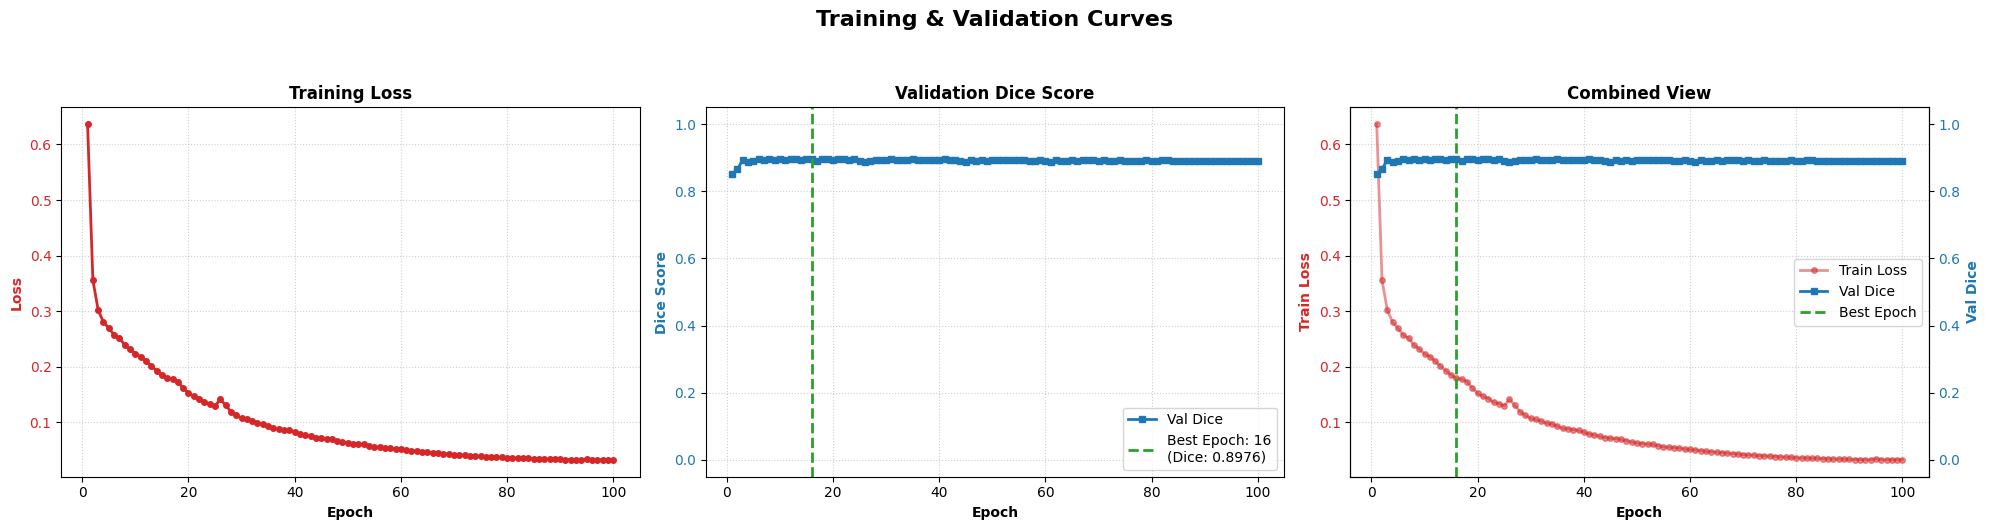

In [17]:
# =====================================================================
# 11) Plot Training Curves (1x3 Grid Sesuai Referensi)
# =====================================================================
import matplotlib.pyplot as plt
import pandas as pd

history = pd.read_csv(CSV_LOG_PATH)
display(history.head())

# Mencari epoch terbaik berdasarkan val_dice tertinggi
best_idx = history["val_dice"].idxmax() 
best_epoch = int(history.loc[best_idx, "epoch"])
best_val_dice = history.loc[best_idx, "val_dice"]

# Ubah layout menjadi 1 baris, 3 kolom
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Konfigurasi warna standar untuk konsistensi
COLOR_LOSS = '#d62728'  # Merah
COLOR_DICE = '#1f77b4'  # Biru
COLOR_BEST = '#2ca02c'  # Hijau

# -----------------------------------------------------------
# 1. Training Loss Plot
# -----------------------------------------------------------
axes[0].plot(history["epoch"], history["train_loss"], 
             color=COLOR_LOSS, marker='o', markersize=4, linewidth=2, label="Train Loss")

axes[0].set_title("Training Loss", fontweight='bold')
axes[0].set_xlabel("Epoch", fontweight='bold')
axes[0].set_ylabel("Loss", color=COLOR_LOSS, fontweight='bold')
axes[0].tick_params(axis='y', labelcolor=COLOR_LOSS)
axes[0].grid(True, linestyle=':', alpha=0.6)

# -----------------------------------------------------------
# 2. Validation Dice Score Plot
# -----------------------------------------------------------
axes[1].plot(history["epoch"], history["val_dice"], 
             color=COLOR_DICE, marker='s', markersize=4, linewidth=2, label="Val Dice")

# Garis vertikal best epoch
axes[1].axvline(x=best_epoch, color=COLOR_BEST, linestyle='--', linewidth=2, 
                label=f'Best Epoch: {best_epoch}\n(Dice: {best_val_dice:.4f})')

axes[1].set_title("Validation Dice Score", fontweight='bold')
axes[1].set_xlabel("Epoch", fontweight='bold')
axes[1].set_ylabel("Dice Score", color=COLOR_DICE, fontweight='bold')
axes[1].tick_params(axis='y', labelcolor=COLOR_DICE)
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle=':', alpha=0.6)

# -----------------------------------------------------------
# 3. Combined View Plot (Dual Y-Axis)
# -----------------------------------------------------------
ax3_left = axes[2] 
ax3_right = ax3_left.twinx() # Membuat sumbu Y kedua yang berbagi sumbu X yang sama

# Plot Loss di sumbu kiri (dibuat sedikit transparan agar tidak menutupi Dice)
line1 = ax3_left.plot(history["epoch"], history["train_loss"], 
                      color=COLOR_LOSS, marker='o', markersize=4, alpha=0.5, linewidth=2, label="Train Loss")

# Plot Dice di sumbu kanan
line2 = ax3_right.plot(history["epoch"], history["val_dice"], 
                       color=COLOR_DICE, marker='s', markersize=4, linewidth=2, label="Val Dice")

# Garis vertikal best epoch
line3 = ax3_left.axvline(x=best_epoch, color=COLOR_BEST, linestyle='--', linewidth=2, label="Best Epoch")

ax3_left.set_title("Combined View", fontweight='bold')
ax3_left.set_xlabel("Epoch", fontweight='bold')

# Label Sumbu Kiri (Loss)
ax3_left.set_ylabel("Train Loss", color=COLOR_LOSS, fontweight='bold')
ax3_left.tick_params(axis='y', labelcolor=COLOR_LOSS)

# Label Sumbu Kanan (Dice)
ax3_right.set_ylabel("Val Dice", color=COLOR_DICE, fontweight='bold')
ax3_right.tick_params(axis='y', labelcolor=COLOR_DICE)
ax3_right.set_ylim(-0.05, 1.05)

# Menggabungkan legend dari kedua sumbu
lines = line1 + line2 + [line3]
labels = [l.get_label() for l in lines]
ax3_right.legend(lines, labels, loc='center right')

ax3_left.grid(True, linestyle=':', alpha=0.6)

# -----------------------------------------------------------
# Finalisasi Tampilan
# -----------------------------------------------------------
plt.suptitle("Training & Validation Curves", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Jumlah epoch : 100


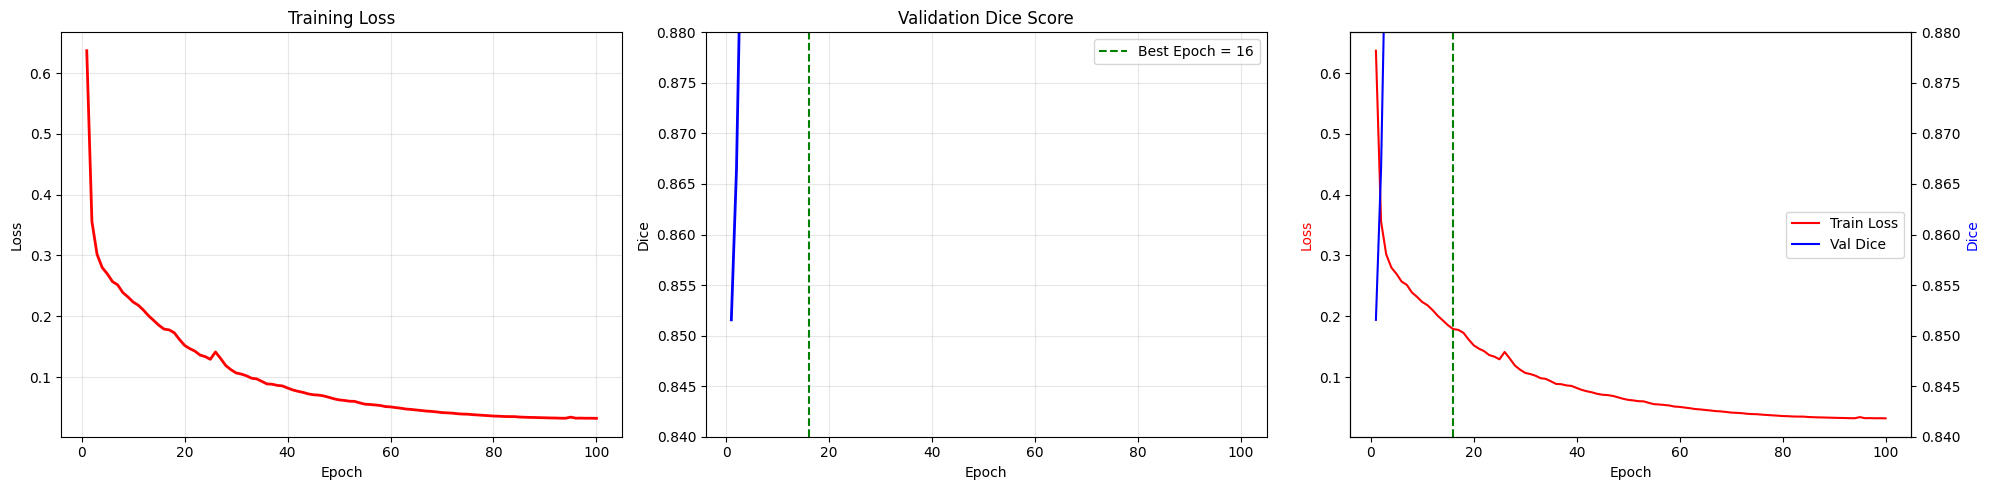

Total epoch : 100
Best epoch  : 16
Best Dice   : 0.8976


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Ganti dengan nama file CSV yang kamu upload
history = pd.read_csv("/kaggle/working/resnet50_unet_artifacts_scale05/history.csv")   # <-- sesuaikan path

# Pastikan terbaca 100 epoch
print("Jumlah epoch :", len(history))

best_idx = history["val_dice"].idxmax()
best_epoch = int(history.loc[best_idx, "epoch"])
best_dice = history.loc[best_idx, "val_dice"]

fig, axes = plt.subplots(1,3,figsize=(20,5))

# ==========================
# Training Loss
# ==========================
axes[0].plot(history["epoch"],
             history["train_loss"],
             color="red",
             linewidth=2)

axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

# ==========================
# Validation Dice
# ==========================
axes[1].plot(history["epoch"],
             history["val_dice"],
             color="blue",
             linewidth=2)

axes[1].axvline(best_epoch,
                color="green",
                linestyle="--",
                label=f"Best Epoch = {best_epoch}")

axes[1].scatter(best_epoch,
                best_dice,
                color="green",
                s=60)

axes[1].legend()
axes[1].set_ylim(0.84,0.88)
axes[1].set_title("Validation Dice Score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].grid(alpha=0.3)

# ==========================
# Combined
# ==========================
ax1 = axes[2]
ax2 = ax1.twinx()

l1 = ax1.plot(history["epoch"],
              history["train_loss"],
              color="red",
              label="Train Loss")

l2 = ax2.plot(history["epoch"],
              history["val_dice"],
              color="blue",
              label="Val Dice")

ax1.axvline(best_epoch,
            color="green",
            linestyle="--")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss",color="red")
ax2.set_ylabel("Dice",color="blue")
ax2.set_ylim(0.84,0.88)

lines = l1+l2
labels = [l.get_label() for l in lines]
ax2.legend(lines,labels,loc="center right")

plt.tight_layout()
plt.show()

print(f"Total epoch : {len(history)}")
print(f"Best epoch  : {best_epoch}")
print(f"Best Dice   : {best_dice:.4f}")

## Bagian 13 -- Quick Inference Preview

Visualisasi prediksi model pada satu sampel dari validation set.

Dari U-Net [R2]:
> *"At the output layer, a per-pixel softmax classifier assigns each pixel
> to one of the segmentation classes."*

Di sini:
- **Binary**: logits -> sigmoid -> threshold 0.5 -> mask biner {0, 1}
- **Multiclass**: logits -> argmax(dim=1) -> class index per pixel

Tiga panel: gambar asli | ground truth mask | prediksi model.

In [19]:
# =====================================================================
# 13) Quick Inference Preview
# =====================================================================
# [R2] Ronneberger et al. (2015): U-Net output -> per-pixel classification
# Binary  : sigmoid(logits) > threshold -> {0, 1}
# Multiclass: argmax(logits, dim=1)     -> class index
# =====================================================================

@torch.no_grad() 
def predict_sample(dataset, idx=0, threshold=0.5):
    # Inference satu sampel dan tampilkan visualisasi (3 panel)
    image, mask = dataset[idx]
    x = image.unsqueeze(0).to(DEVICE)   # (1, C, H, W)
    logits = model_eval(x)              # forward pass [R2]

    # De-normalisasi sebelum display: tensor sudah ternormalisasi ImageNet [R3][R4]
    # denorm_for_display() mengembalikan ke [0,1] float, siap untuk plt.imshow()
    img = denorm_for_display(image, valid_dataset)

    if TASK_TYPE == "binary":
        # sigmoid: logits -> probabilitas; threshold -> mask biner {0,1}
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
        pred = (prob > threshold).astype(np.float32)
        gt   = mask.squeeze(0).cpu().numpy()

        plt.figure(figsize=(13, 4))
        plt.subplot(1, 3, 1); plt.title("Image");             plt.imshow(img);           plt.axis("off")
        plt.subplot(1, 3, 2); plt.title("Ground Truth Mask"); plt.imshow(gt,   cmap="gray"); plt.axis("off")
        plt.subplot(1, 3, 3); plt.title("Prediction");        plt.imshow(pred, cmap="gray"); plt.axis("off")
    else:
        # argmax dim=1: class index per pixel
        pred = torch.argmax(logits, dim=1)[0].cpu().numpy()
        gt   = mask.cpu().numpy()

        plt.figure(figsize=(13, 4))
        plt.subplot(1, 3, 1); plt.title("Image");             plt.imshow(img);           plt.axis("off")
        plt.subplot(1, 3, 2); plt.title("Ground Truth Mask"); plt.imshow(gt,   cmap="tab20"); plt.axis("off")
        plt.subplot(1, 3, 3); plt.title("Prediction");        plt.imshow(pred, cmap="tab20"); plt.axis("off")

    plt.tight_layout(); plt.show()

predict_sample(valid_dataset, 0)

TypeError: denorm_for_display() takes 1 positional argument but 2 were given

## Bagian 14 -- Pack & Download Artifacts

Menggabungkan semua output training ke satu file ZIP.

File yang disertakan:
- `best.pt`    -- checkpoint model terbaik, portabel tanpa DataParallel [R5]
- `last.pt`    -- checkpoint epoch terakhir
- `history.csv`-- log metrik per epoch (loss, dice, IoU, lr)
- `tb_logs/`   -- TensorBoard event files

In [24]:
import os
from IPython.display import FileLink

# Pindah ke direktori working agar FileLink membaca path relatif dengan benar
# os.chdir('/kaggle/working/')
     
# Path relatif ke file dari /kaggle/working/
file_path = "/kaggle/working/resnet50_unet_artifacts_scale05/best.pt"
 
if os.path.exists(file_path):
    display(FileLink(file_path))
else:
    print("File tidak ditemukan. Pastikan proses training sudah selesai dan direktori benar.")

/kaggle/working/resnet50_unet_artifacts_scale05/best.pt

In [23]:
# =====================================================================
# 14) Pack and Download Artifacts
# =====================================================================
archive_name = str(MODEL_DIR) + "_artifacts"
shutil.make_archive(archive_name, "zip", root_dir=str(MODEL_DIR))
print(f"Artifacts ZIP  : {archive_name}.zip")
print(f"  best.pt      - best checkpoint ResNet50-UNet epoch {best_ckpt['epoch']} [R1][R2]")
print( "  last.pt      - last epoch checkpoint")
print( "  history.csv  - training log (loss/dice/IoU/lr per epoch)")
print( "  tb_logs/     - TensorBoard logs")

# Download otomatis jika berjalan di Google Colab
try:
    from google.colab import files   
    files.download(archive_name + ".zip")
except Exception: 
    print("\nUntuk Kaggle: klik Output di sidebar -> download ZIP secara manual.")

Artifacts ZIP  : resnet50_unet_artifacts_scale05_artifacts.zip
  best.pt      - best checkpoint ResNet50-UNet epoch 16 [R1][R2]
  last.pt      - last epoch checkpoint
  history.csv  - training log (loss/dice/IoU/lr per epoch)
  tb_logs/     - TensorBoard logs


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import os
import zipfile
from IPython.display import FileLink, display

best_pt = "/kaggle/working/resnet50_unet_artifacts_scale05/best.pt"
history_csv = "/kaggle/working/resnet50_unet_artifacts_scale05/history.csv"

zip_path = "/kaggle/working/resnet50_unet_artifacts_scale05.zip"

# Cek file ada
for f in [best_pt, history_csv]:
    if not os.path.exists(f):
        raise FileNotFoundError(f"File tidak ditemukan: {f}")

# Buat zip
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(best_pt, arcname="best.pt")
    zf.write(history_csv, arcname="history.csv")

print("ZIP berhasil dibuat:", zip_path)

# Tampilkan link download
display(FileLink(zip_path))

ZIP berhasil dibuat: /kaggle/working/resnet50_unet_artifacts_scale05.zip


/kaggle/working/resnet50_unet_artifacts_scale05.zip

## Daftar Referensi Lengkap

### Paper / Publikasi Ilmiah

1. **[R1]** He, K., Zhang, X., Ren, S., & Sun, J. (2016).
   *Deep Residual Learning for Image Recognition.*
   IEEE CVPR 2016. [arXiv:1512.03385](https://arxiv.org/abs/1512.03385)

2. **[R2]** Ronneberger, O., Fischer, P., & Brox, T. (2015).
   *U-Net: Convolutional Networks for Biomedical Image Segmentation.*
   MICCAI 2015. [arXiv:1505.04597](https://arxiv.org/abs/1505.04597)

3. **[R6]** Loshchilov, I., & Hutter, F. (2019).
   *Decoupled Weight Decay Regularization.*
   ICLR 2019. [arXiv:1711.05101](https://arxiv.org/abs/1711.05101)

4. **[R7]** Micikevicius, P., et al. (2018).
   *Mixed Precision Training.*
   ICLR 2018. [arXiv:1710.03740](https://arxiv.org/abs/1710.03740)

5. **[R8]** Milletari, F., Navab, N., & Ahmadi, S. A. (2016).
   *V-Net: Fully Convolutional Neural Networks for Volumetric Medical Image Segmentation.*
   3DV 2016. [arXiv:1606.04797](https://arxiv.org/abs/1606.04797)

### Dokumentasi Resmi & Library

6. **[R3]** PyTorch / TorchVision. (2024).
   *torchvision.models.resnet50 -- Official API.*
   https://pytorch.org/vision/stable/models/generated/torchvision.models.resnet50.html

7. **[R4]** Iakubovskii, P. (2019).
   *Segmentation Models PyTorch.*
   GitHub: https://github.com/qubvel/segmentation_models.pytorch

8. **[R5]** PyTorch. (2024).
   *torch.nn.DataParallel -- Multi-GPU Training.*
   https://pytorch.org/docs/stable/generated/torch.nn.DataParallel.html
   Saving DataParallel Models:
   https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-torch-nn-dataparallel-models

9. PyTorch. (2024). *Automatic Mixed Precision (AMP).*
   https://pytorch.org/docs/stable/amp.html

10. PyTorch. (2024). *DataLoader & Dataset.*
    https://pytorch.org/docs/stable/data.html